# Bioypthon Exercises

In [1]:
from Bio.PDB import PDBList, PDBParser, MMCIFParser
import numpy as np
import matplotlib.pyplot as plt

-------------------
# Exercise 1
--------------------
- PDB: 3GOE
- Extract the carbon alpha coordinates of the protein without the N-terminal histidine tag (ﬁrst 6
residues) nor the water and ion atoms (hetero atoms).
- Create a all-to-all contact map for the protein residues using the
coordinates array we generated previously. Use 6 Å and 12 Å as
the inner and outer cutoﬀs, respectively.

In [2]:
pdb_code = "3goe"
pdbl = PDBList(server = "https://files.rcsb.org")
pdbl.retrieve_pdb_file(pdb_code = f"{pdb_code}", pdir = "./Data/", file_format = "mmCif")

Structure exists: './Data/3goe.cif' 


'./Data/3goe.cif'

In [3]:
parser = MMCIFParser()

structure = parser.get_structure("myprotein", f"./Data/{pdb_code}.cif")
print("Models:", list(structure))
print("- > Chains:", list(structure[0]))
print("- -  > Residues:", len(list(structure[0]['A'])))

chain = structure[0]['A']

Models: [<Model id=0>]
- > Chains: [<Chain id=A>]
- -  > Residues: 162


In [4]:
all_residues_names = [r.get_resname() for r in chain.get_residues()]
print(np.unique(all_residues_names)) # HOH = water, "OXY", "HEM"

['ARG' 'ASN' 'ASP' 'CA' 'CYS' 'GLN' 'GLU' 'GLY' 'HIS' 'HOH' 'ILE' 'LEU'
 'LYS' 'PHE' 'PRO' 'SER' 'THR' 'TRP' 'TYR' 'VAL']


In [5]:
residues = list(chain.get_residues())
all_ids = []
for i, r in enumerate(residues):
    all_ids.append(r.get_id()[0])
print(np.unique(all_ids))

[' ' 'H_CA' 'W']


In [6]:
import requests

def get_ligand_description(residue_code):
    """Fetches the full name of a PDB residue code via the RCSB API."""
    url = f"https://data.rcsb.org/rest/v1/core/chemcomp/{residue_code}"
    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        return data['chem_comp']['name'], data['chem_comp']['formula']
    return "Unknown", "N/A"


codes_to_check = ['OXY', 'CA']
for code in codes_to_check:
    name, formula = get_ligand_description(code)
    print(f"{code} -> {name} (Formula: {formula})")

OXY -> OXYGEN MOLECULE (Formula: O2)
CA -> CALCIUM ION (Formula: Ca)


- ' ': amino-acid
- 'H_HEM': hem group
- 'H_OXY': ...
- 'W': water molecule


In general: 'H_XXX' stands for H: heteroatom, XXX: the specific ligand.

In [7]:
### Reconstruct the SEQUENCE,excluding the heteroatoms (ligands and water molecules) 
# that are present in the PDB coordinates

from Bio.PDB.Polypeptide import PPBuilder, Polypeptide

#for pp in ppb.build_peptides(structure):
#    print(pp.get_sequence())


# Remove heteroatoms
ppb = PPBuilder()
pp_objects = ppb.build_peptides(chain, aa_only = True) # one peptide object per each discontinuous chain

peptide = pp_objects[0]
clean_peptide = Polypeptide(peptide[6:]) # Remove Histidine tag, re-build Peptide object


print(peptide.get_sequence())
print(clean_peptide.get_sequence())
length = len(clean_peptide.get_sequence())
print(length)

HHHHHHKLITLLLRSSKSEDLRLSIPVDFTVKDLIKRYCTEVKISFHERIRLEFEGEWLDPNDQVQSTELEDEDQVSVVL
KLITLLLRSSKSEDLRLSIPVDFTVKDLIKRYCTEVKISFHERIRLEFEGEWLDPNDQVQSTELEDEDQVSVVL
74


Text(0.5, 1.0, 'Contact Map')

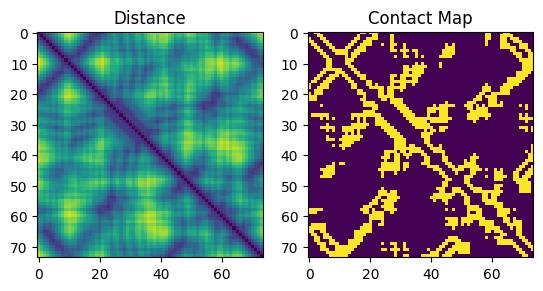

In [8]:
ca_atoms = clean_peptide.get_ca_list()
#coords = [ca.get_coord() for ca in ca_atoms]
#print(coords)

distance = np.zeros((length, length))
for i in range(length):
    for j in range(length):
        distance[i,j] = ca_atoms[i] - ca_atoms[j]



contact_map = np.where((distance > 6) & (distance < 12), 1, 0)
fig, axs = plt.subplots(nrows= 1, ncols = 2)

im = axs[0].imshow(distance, origin = "upper")
axs[0].set_title("Distance")
axs[1].imshow(contact_map, origin = "upper")
axs[1].set_title("Contact Map")
#plt.colorbar(im, label = "armstrong")

-------------------
# Exercise 2
--------------------

Let us analyze and describe the structure of human
hemoglobin:

1. Download the mmCIF file from PDB and parse it
2. Extract the sequence of the protein subunits and
obtain the amino acid percentages
3. Identify, for each chain, the residue that is closest to
a Fe atom. Remember to account for all the atoms in each residue, not only the C alpha. Check your result with the PDB structure visualizer.
4. Calculate the radius of gyration of the individual
chains, as well as for the complete structure
5. (Optional) Compare the structure with that of
hemoglobin when bound to oxygens (PDB: 1GZX)


In [9]:
pdb_code = "6fqf"

# 1: Download
from Bio.PDB import PDBList
pdb_list = PDBList(server = "https://files.rcsb.org")
pdb_list.retrieve_pdb_file(pdb_code = pdb_code, pdir = "./Data/", file_format = "mmCif")


# 2: Parse
from Bio.PDB import MMCIFParser
parser = MMCIFParser()
structure = parser.get_structure(structure_id = "hemoglobin", filename = f"./Data/{pdb_code}.cif")

print("Structure: ", structure)
print("-> Model: ", list(structure[0]))
print("--> Chain: ", list(structure[0]['A']))

Structure exists: './Data/6fqf.cif' 
Structure:  <Structure id=hemoglobin>
-> Model:  [<Chain id=A>, <Chain id=B>, <Chain id=C>, <Chain id=D>]
--> Chain:  [<Residue VAL het=  resseq=1 icode= >, <Residue HIS het=  resseq=2 icode= >, <Residue LEU het=  resseq=3 icode= >, <Residue THR het=  resseq=4 icode= >, <Residue PRO het=  resseq=5 icode= >, <Residue GLU het=  resseq=6 icode= >, <Residue GLU het=  resseq=7 icode= >, <Residue LYS het=  resseq=8 icode= >, <Residue SER het=  resseq=9 icode= >, <Residue ALA het=  resseq=10 icode= >, <Residue VAL het=  resseq=11 icode= >, <Residue THR het=  resseq=12 icode= >, <Residue ALA het=  resseq=13 icode= >, <Residue LEU het=  resseq=14 icode= >, <Residue TRP het=  resseq=15 icode= >, <Residue GLY het=  resseq=16 icode= >, <Residue LYS het=  resseq=17 icode= >, <Residue VAL het=  resseq=18 icode= >, <Residue ASN het=  resseq=19 icode= >, <Residue VAL het=  resseq=20 icode= >, <Residue ASP het=  resseq=21 icode= >, <Residue GLU het=  resseq=22 icode

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 4492.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 4535.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain C is discontinuous at line 4578.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain D is discontinuous at line 4621.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 4664.
  warni

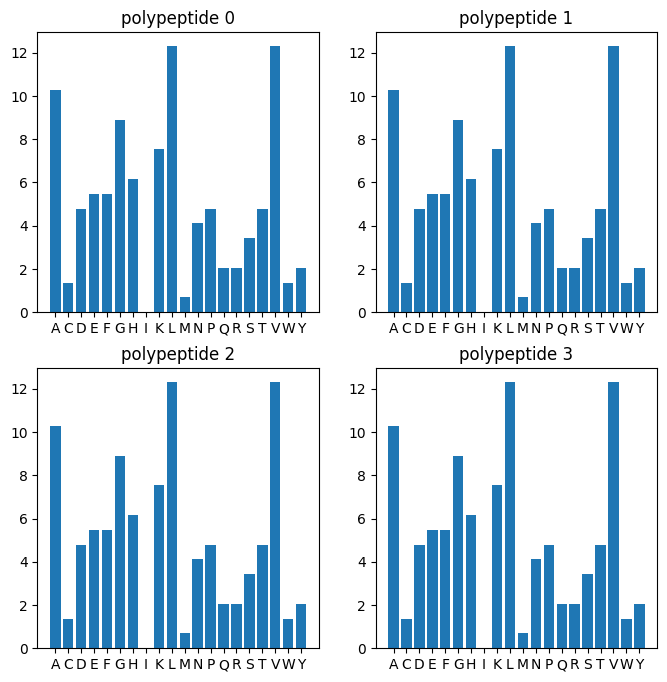

In [10]:
# Aminoacid Composition
from Bio.PDB.Polypeptide import PPBuilder
from Bio.SeqUtils.ProtParam import ProteinAnalysis


ppb = PPBuilder()
polipeptides = ppb.build_peptides(structure[0], aa_only = True)


fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (8,8))
axs = axs.flatten()
for i, polip in enumerate(polipeptides):
    seq = polip.get_sequence()
    seq_analysis = ProteinAnalysis(seq)
    dict = seq_analysis.amino_acids_percent
    axs[i].bar(list(dict.keys()), dict.values())
    axs[i].set_title(f"polypeptide {i}")

plt.show()

In [11]:
# Identify the closest atom to the Fe atom, for each chain. Remeber to consider all atoms in a residue, not just the Ca.
all_ids = [res.get_id()[0] for res in structure[0]['A'].get_residues()]
print(np.unique(all_ids)) # look for 'H_HEM'




for chain in structure[0]:

    # identify Fe : each chain contains one Fe atom inside the HEM group
    for residue in chain.get_residues():
        if residue.get_id()[0] == 'H_HEM':
            for atom in residue.get_atoms():
                if atom.name == "FE":
                    fe_atom = atom
    

    best_residue = None
    best_atom = None
    min_distance = 10e9

    for residue in chain.get_residues():
        if residue.get_id()[0] == ' ':
            for atom in residue.get_atoms():
                distance = atom - fe_atom
                if distance < min_distance:
                    best_residue = residue
                    best_atom = atom
                    min_distance = distance
    print(f"Chain: {chain}, best residue: {best_residue.get_id}, best atom: {best_atom}, distance: {min_distance}")

[' ' 'H_HEM' 'W']
Chain: <Chain id=A>, best residue: <bound method Entity.get_id of <Residue HIS het=  resseq=92 icode= >>, best atom: <Atom NE2>, distance: 2.1153526306152344
Chain: <Chain id=B>, best residue: <bound method Entity.get_id of <Residue HIS het=  resseq=92 icode= >>, best atom: <Atom NE2>, distance: 2.1003458499908447
Chain: <Chain id=C>, best residue: <bound method Entity.get_id of <Residue HIS het=  resseq=92 icode= >>, best atom: <Atom NE2>, distance: 2.0663158893585205
Chain: <Chain id=D>, best residue: <bound method Entity.get_id of <Residue HIS het=  resseq=92 icode= >>, best atom: <Atom NE2>, distance: 2.181626081466675


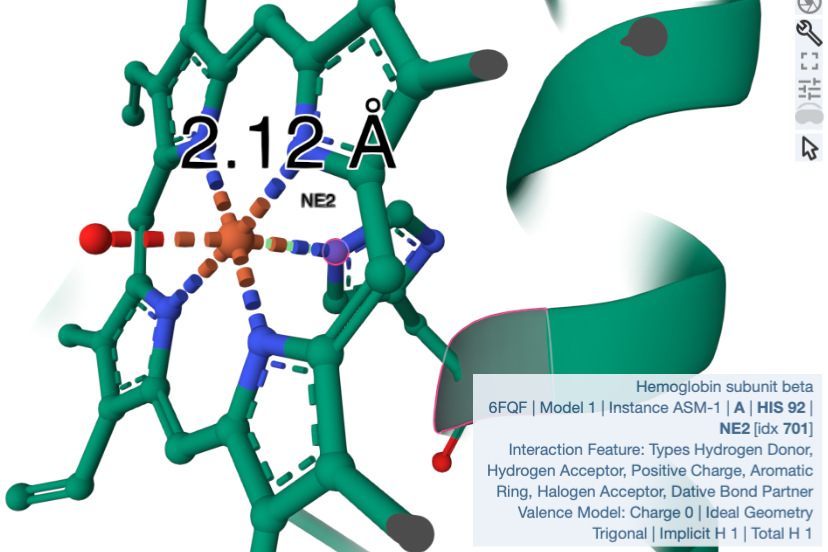

In [12]:
from IPython import display

display.Image("histidine_ne.png")

In [19]:
# Radius of gyration - single chains and whole assembly



def get_radius_gyration(object):
    residues = [r for r in object.get_residues() if r.get_id()[0] == " "] # only get aa
    # compute (geometric: non weighted) CM
    CA_coords = np.vstack([r['CA'].get_coord() for r in residues])
    cm = np.mean(CA_coords, axis = 0)
    print("center of mass: ", cm)
    square_distances = [(cm - r['CA'].get_coord())**2 for r in residues]
    return np.sqrt(np.mean(square_distances))


print(get_radius_gyration(structure[0]['A']))
print(get_radius_gyration(structure[0]['B']))
print(get_radius_gyration(structure[0]['C']))
print(get_radius_gyration(structure[0]['D']))
print(get_radius_gyration(structure[0]))

center of mass:  [16.614523 16.48972  10.314861]
8.566542
center of mass:  [ 22.153946 -11.689551  22.922478]
8.579867
center of mass:  [ 0.1658356 -4.062944  27.780087 ]
8.553726
center of mass:  [ 6.7972    -0.7089591 -2.6431508]
8.568256
center of mass:  [1.1432875e+01 7.0653027e-03 1.4593568e+01]
13.401502


In [14]:
pdb_code_oxigens = "1gzx"



# 1: Download
from Bio.PDB import PDBList
pdb_list = PDBList(server = "https://files.rcsb.org")
pdb_list.retrieve_pdb_file(pdb_code = pdb_code_oxigens, pdir = "./Data/", file_format = "mmCif")


# 2: Parse
from Bio.PDB import MMCIFParser
parser = MMCIFParser()
structure_oxy = parser.get_structure(structure_id = "hemoglobin", filename = f"./Data/{pdb_code_oxigens}.cif")

print("Structure: ", structure_oxy)
print("-> Model: ", list(structure_oxy[0]))
print("--> Chain: ", list(structure_oxy[0]['A']))

Structure exists: './Data/1gzx.cif' 
Structure:  <Structure id=hemoglobin>
-> Model:  [<Chain id=A>, <Chain id=B>, <Chain id=C>, <Chain id=D>]
--> Chain:  [<Residue VAL het=  resseq=1 icode= >, <Residue LEU het=  resseq=2 icode= >, <Residue SER het=  resseq=3 icode= >, <Residue PRO het=  resseq=4 icode= >, <Residue ALA het=  resseq=5 icode= >, <Residue ASP het=  resseq=6 icode= >, <Residue LYS het=  resseq=7 icode= >, <Residue THR het=  resseq=8 icode= >, <Residue ASN het=  resseq=9 icode= >, <Residue VAL het=  resseq=10 icode= >, <Residue LYS het=  resseq=11 icode= >, <Residue ALA het=  resseq=12 icode= >, <Residue ALA het=  resseq=13 icode= >, <Residue TRP het=  resseq=14 icode= >, <Residue GLY het=  resseq=15 icode= >, <Residue LYS het=  resseq=16 icode= >, <Residue VAL het=  resseq=17 icode= >, <Residue GLY het=  resseq=18 icode= >, <Residue ALA het=  resseq=19 icode= >, <Residue HIS het=  resseq=20 icode= >, <Residue ALA het=  resseq=21 icode= >, <Residue GLY het=  resseq=22 icode

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 4384.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 4429.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain C is discontinuous at line 4474.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain D is discontinuous at line 4519.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 4564.
  warni

Note: while structure 6fqf has 4 identical subunits, the structure 1gzx has two "alpha" and two "beta" subunits, which are different. 

We only compare then the (identical) chains of 6fqf to the beta subunits of 1gzx

In [32]:
# Check residue identity

def compare_residues(chain_A, chain_B):
    residue_list_A = [r for r in chain_A.get_residues() if r.get_id()[0] == ' ']
    residue_list_B = [r for r in chain_B.get_residues()  if r.get_id()[0] == ' ']

    for i, r in enumerate(residue_list_A):
        if i < min(len(residue_list_A), len(residue_list_B)):
            res_b =  residue_list_B[i]
            if r.get_resname() != res_b.get_resname():
                print(f"Mismatch at position {i}: {r.get_resname()} / {res_b.get_resname()}")

In [36]:
#compare_residues(structure[0]['A'], structure_oxy[0]['A'])  # all mismatched! they are different polipeptides

compare_residues(structure[0]['A'], structure_oxy[0]['B']) # instead, these are the same

In [ ]:
from Bio.PDB import Superimposer

superimposer = Superimposer()
ref_model = structure[0]['A']
alt_model = structure_oxy[0]['B']


ca_atoms = []
for res in ref_model.get_residues():
    if res.get_id()[0] == ' ':
        ca_atoms.append(res['CA']) # ensure you only call ['CA'] for aminoacid residues
        #for atom in res.get_atoms():
        #    if atom.id == 'CA':
        #        ca_atoms.append(atom)


ca_atoms_alt= []
for res in alt_model.get_residues():
    if res.get_id()[0] == ' ':
        for atom in res.get_atoms():
            if atom.id == 'CA':
                ca_atoms_alt.append(atom)


len(ca_atoms_alt)

superimposer.set_atoms(fixed = ca_atoms, moving = ca_atoms_alt) # define the frame based on CA atom positions
superimposer.apply(alt_model.get_atoms()) # rotate- traslate ALL the atoms (not just CA)
print(superimposer.rms)

0.9043722671578598


In [45]:
# Finally, lets compute the deviation for each residue, to check which parts of the chain are more mobile



def compute_residue_deviation(chain_A, chain_B):
    deviations = []
    carbons_chain_A = [r['CA'] for r in chain_A.get_residues() if r.get_id()[0] == ' ']
    carbons_chain_B = [r['CA'] for r in chain_B.get_residues()  if r.get_id()[0] == ' ']
    deviations = [ca - cb for ca, cb in zip(carbons_chain_A, carbons_chain_B)]
    return deviations
            

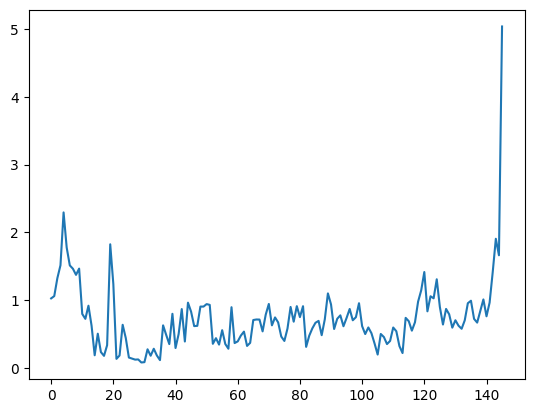

In [47]:
dev = compute_residue_deviation(ref_model, alt_model)
plt.plot(range(len(dev)), dev)

I dont know if what I did is exactly what I needed to do, but I will find out when I will need to solve an actual problem.